In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import statsmodels.api as sm

sys.path.append("..")
from scripts.database import engine

✅ Conexión engine lista


In [2]:
df = pd.read_sql("SELECT * FROM pokemon", engine)
df.head()

,id,name,height,weight,base_experience,types
0,1,bulbasaur,7,69,64,"grass, poison"
1,2,ivysaur,10,130,142,"grass, poison"
2,3,venusaur,20,1000,236,"grass, poison"
3,4,charmander,6,85,62,fire
4,5,charmeleon,11,190,142,fire


In [4]:
df = df.dropna(subset=["height", "weight", "base_experience"])
df.shape

(20, 6)

In [5]:
FEATURES = ["height", "weight"]

X = df[FEATURES]
y = df["base_experience"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
pred = model.predict(X_test)

In [10]:
print("R2 score:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("MAE:", mean_absolute_error(y_test, pred))

R2 score: 0.9177295675984576
MSE: 364.4580155388326
RMSE: 19.090783523439594
MAE: 15.88363922852181


In [11]:
print("Intercept:", model.intercept_)
print("Coeficientes:", model.coef_)

Intercept: 12.609107470532734
Coeficientes: [11.47451032  0.03013188]


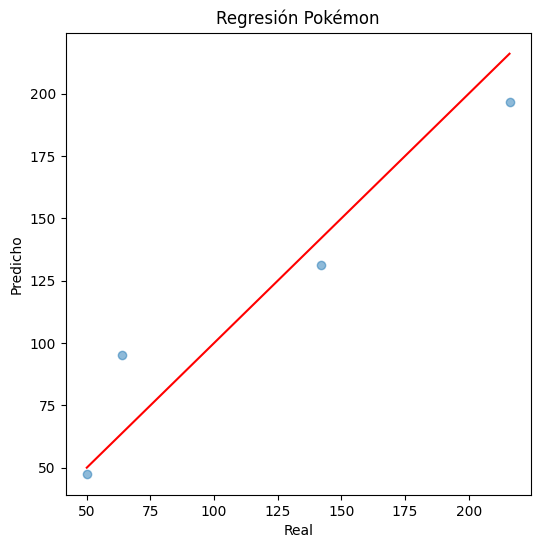

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.5)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Regresión Pokémon")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

In [13]:
X_ols = sm.add_constant(X)
model_ols = sm.OLS(y, X_ols).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:        base_experience   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     73.93
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           4.10e-09
Time:                        22:58:29   Log-Likelihood:                -90.502
No. Observations:                  20   AIC:                             187.0
Df Residuals:                      17   BIC:                             190.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7410     15.684      0.430      0.6